In [4]:
import os

os.listdir("../data")

['test.csv', 'train.csv']

In [5]:
import pandas as pd

train = pd.read_csv(
    "../data/train.csv"
)

train.head()

,timestamp,value,label,KPI ID
0,1493568000,1.901639,0,02e99bd4f6cfb33f
1,1493568060,1.786885,0,02e99bd4f6cfb33f
2,1493568120,2.000000,0,02e99bd4f6cfb33f
3,1493568180,1.885246,0,02e99bd4f6cfb33f
4,1493568240,1.819672,0,02e99bd4f6cfb33f


In [6]:
train.shape

(2476315, 4)

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2476315 entries, 0 to 2476314
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   timestamp  int64  
 1   value      float64
 2   label      int64  
 3   KPI ID     str    
dtypes: float64(1), int64(2), str(1)
memory usage: 75.6 MB


In [8]:
train["timestamp"] = pd.to_datetime(
    train["timestamp"],
    unit="s",
)

In [9]:
train["timestamp"]

0         2017-04-30 16:00:00
1         2017-04-30 16:01:00
2         2017-04-30 16:02:00
3         2017-04-30 16:03:00
4         2017-04-30 16:04:00
                  ...        
2476310   2017-06-08 04:15:00
2476311   2017-06-08 04:16:00
2476312   2017-06-08 04:17:00
2476313   2017-06-08 04:18:00
2476314   2017-06-08 04:19:00
Name: timestamp, Length: 2476315, dtype: datetime64[s]

In [10]:
train["KPI ID"].nunique()

26

In [11]:
train["KPI ID"].value_counts()

KPI ID
7c189dd36f048a6c    147689
affb01ca2b4f0b45    147680
71595dd7171f4540    147668
cff6d3c01e6a6bfa    147629
e0770391decc44ce    147024
8c892e5525f3e491    147009
a40b1df87e3f1c87    137925
8bef9af9a922e0b3    129453
18fbb1d5a5dc099d    129128
da403e4e3f87c9e0    129035
09513ae3e75778a3    128971
1c35dbf57f55f5e4    128853
a5bf5d65261d859a    128679
c58bfcbacb2822d1    128667
9bd90500bfd11edb    128613
02e99bd4f6cfb33f    128562
40e25005ff8992bd    100254
9ee5879409dccef9     65449
88cf3a776ba00e7c     65436
07927a9a18fa19ae     10960
046ec29ddf80d62e      8784
8a20c229e9860d0c      8784
769894baefea4e9e      8784
76f4550c43334374      8784
54e8a140f6237526      8248
b3b2e6d1a791d63a      8247
Name: count, dtype: int64

In [12]:
train["timestamp"].min()

Timestamp('2016-06-30 16:00:00')

In [13]:
train["timestamp"].max()

Timestamp('2017-08-11 10:20:00')

In [14]:
train["label"].value_counts()

label
0    2422815
1      53500
Name: count, dtype: int64

In [15]:
train["label"].value_counts(normalize=True)

label
0    0.978395
1    0.021605
Name: proportion, dtype: float64

Normal points chiếm 97.8%
Anomalies points chiếm 2.2%

In [16]:
train.groupby("KPI ID")["label"].mean()

KPI ID
02e99bd4f6cfb33f    0.082062
046ec29ddf80d62e    0.009107
07927a9a18fa19ae    0.011861
09513ae3e75778a3    0.001845
18fbb1d5a5dc099d    0.060893
1c35dbf57f55f5e4    0.074356
40e25005ff8992bd    0.006523
54e8a140f6237526    0.000485
71595dd7171f4540    0.007537
769894baefea4e9e    0.001025
76f4550c43334374    0.009904
7c189dd36f048a6c    0.002884
88cf3a776ba00e7c    0.047466
8a20c229e9860d0c    0.000455
8bef9af9a922e0b3    0.004071
8c892e5525f3e491    0.020972
9bd90500bfd11edb    0.001112
9ee5879409dccef9    0.044997
a40b1df87e3f1c87    0.002762
a5bf5d65261d859a    0.000225
affb01ca2b4f0b45    0.003954
b3b2e6d1a791d63a    0.001455
c58bfcbacb2822d1    0.000964
cff6d3c01e6a6bfa    0.007363
da403e4e3f87c9e0    0.059410
e0770391decc44ce    0.020908
Name: label, dtype: float64

Tỷ lệ anomaly giữa các KPI có sự khác biệt đáng kể. Một số KPI có tỷ lệ anomaly trên 8%, trong khi một số KPI khác chỉ có tỷ lệ anomaly dưới 0.1%. Điều này cho thấy mức độ ổn định của các hệ thống hoặc dịch vụ được giám sát là khác nhau. Vì vậy việc sử dụng một ngưỡng cố định hoặc một mô hình duy nhất cho toàn bộ KPI có thể không mang lại hiệu quả tối ưu.


In [17]:
train.isnull().sum()

timestamp    0
value        0
label        0
KPI ID       0
dtype: int64

In [18]:
sampling_stats = []

for kpi_id, group in train.groupby("KPI ID"):

    group = group.sort_values("timestamp")

    diffs = group["timestamp"].diff()

    sampling_stats.append({
        "KPI_ID": kpi_id,
        "mode_interval": diffs.mode()[0],
        "mean_interval": diffs.mean(),
        "std_interval": diffs.std()
    })

sampling_stats = pd.DataFrame(sampling_stats)

In [19]:
sampling_stats

,KPI_ID,mode_interval,mean_interval,std_interval
0,02e99bd4f6cfb33f,0 days 00:01:00,0 days 00:01:01,0 days 00:04:45
1,046ec29ddf80d62e,0 days 00:05:00,0 days 00:05:00,0 days 00:00:00
2,07927a9a18fa19ae,0 days 00:05:00,0 days 00:05:36,0 days 00:27:57
3,09513ae3e75778a3,0 days 00:01:00,0 days 00:01:01,0 days 00:05:01
4,18fbb1d5a5dc099d,0 days 00:01:00,0 days 00:01:01,0 days 00:04:53
5,1c35dbf57f55f5e4,0 days 00:01:00,0 days 00:01:01,0 days 00:05:02
6,40e25005ff8992bd,0 days 00:01:00,0 days 00:01:01,0 days 00:00:09
7,54e8a140f6237526,0 days 00:05:00,0 days 00:05:01,0 days 00:01:12
8,71595dd7171f4540,0 days 00:01:00,0 days 00:01:01,0 days 00:00:49
9,769894baefea4e9e,0 days 00:05:00,0 days 00:05:00,0 days 00:00:00


In [20]:
gap_summary = []

for kpi_id, group in train.groupby("KPI ID"):

    group = group.sort_values("timestamp")

    diffs = group["timestamp"].diff()

    expected = diffs.mode()[0]

    gap_count = (diffs > expected).sum()

    missing_points = (
        diffs[diffs > expected] / expected - 1
    ).sum()

    gap_summary.append({
        "KPI_ID": kpi_id,
        "expected_interval_sec": expected,
        "gap_count": gap_count,
        "missing_points": int(missing_points)
    })

gap_summary = pd.DataFrame(gap_summary)

In [21]:
gap_summary.sort_values(
    "missing_points",
    ascending=False
)

,KPI_ID,expected_interval_sec,gap_count,missing_points
15,8c892e5525f3e491,0 days 00:01:00,2930,4756
25,e0770391decc44ce,0 days 00:01:00,2926,4727
23,cff6d3c01e6a6bfa,0 days 00:01:00,2943,3482
8,71595dd7171f4540,0 days 00:01:00,2938,3401
11,7c189dd36f048a6c,0 days 00:01:00,2931,3371
20,affb01ca2b4f0b45,0 days 00:01:00,2930,3361
0,02e99bd4f6cfb33f,0 days 00:01:00,44,3233
16,9bd90500bfd11edb,0 days 00:01:00,45,3182
22,c58bfcbacb2822d1,0 days 00:01:00,44,3123
19,a5bf5d65261d859a,0 days 00:01:00,46,3111


Kiểm tra dữ liệu cho thấy dataset không có missing values, tuy nhiên vẫn tồn tại hiện tượng data gaps ở một số KPI. Các KPI được thu thập với tần suất chủ yếu là 1 phút/lần, nhưng vẫn xuất hiện những khoảng thời gian bị gián đoạn làm phát sinh missing points.

## Stationarity

In [22]:
selected_kpis = [
    "02e99bd4f6cfb33f",
    "1c35dbf57f55f5e4",
    "18fbb1d5a5dc099d",
    "54e8a140f6237526",
    "8a20c229e9860d0c"
]

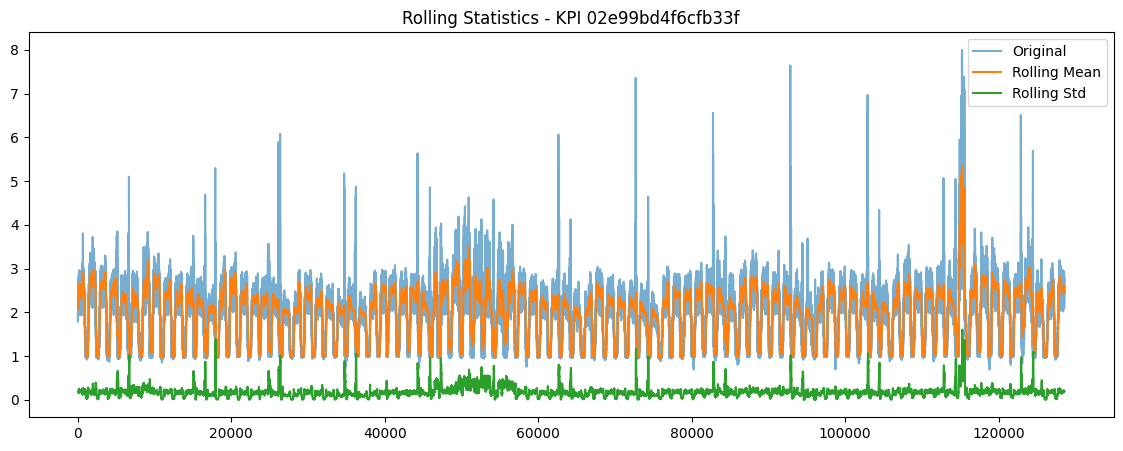

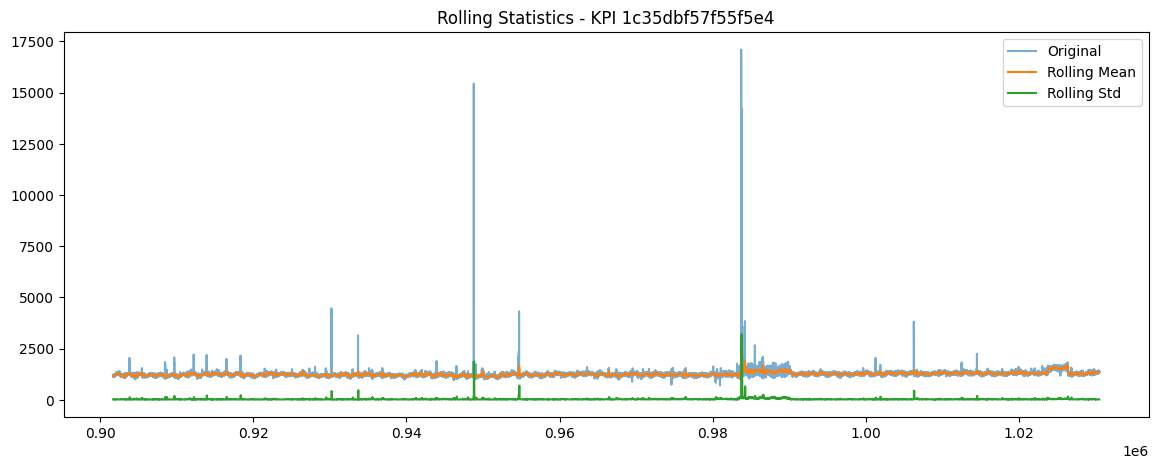

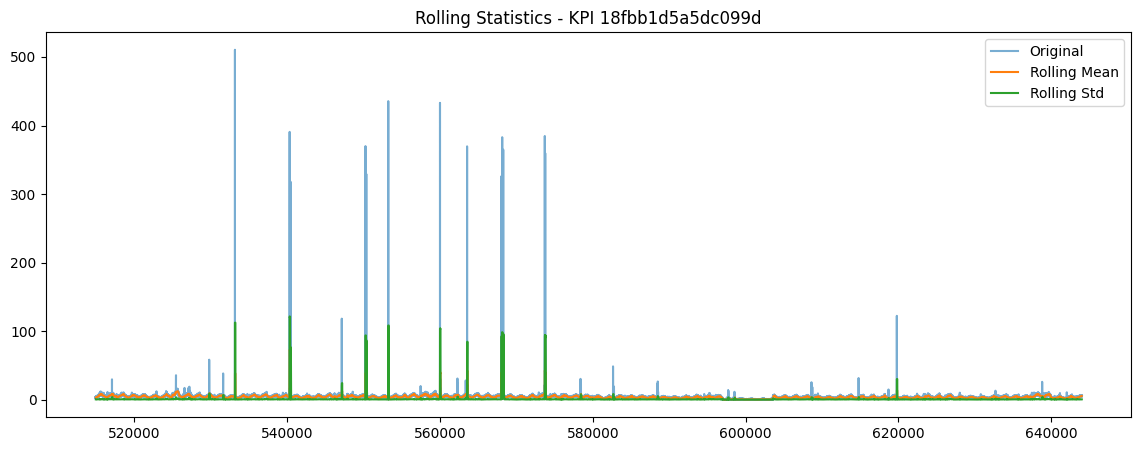

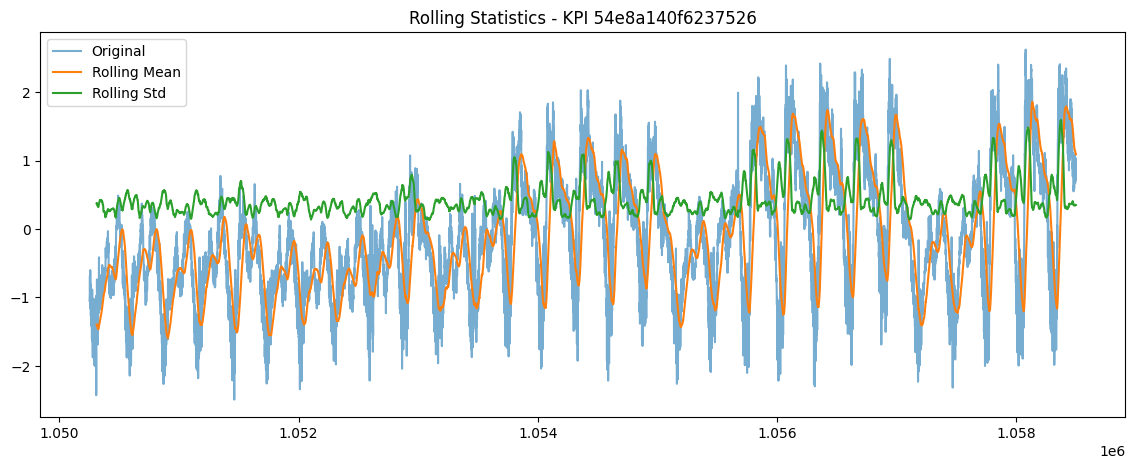

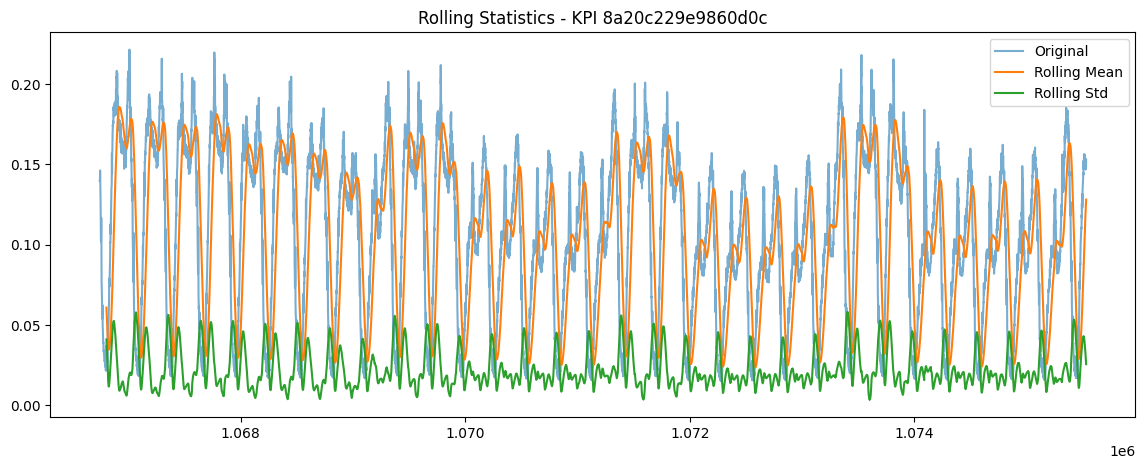

In [23]:
import matplotlib.pyplot as plt 

windows = 60

for kpi_id in selected_kpis:

    kpi_df = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")
        .copy()
    )

    rolling_mean = kpi_df["value"].rolling(window).mean()
    rolling_std = kpi_df["value"].rolling(window).std()

    plt.figure(figsize=(14,5))

    plt.plot(kpi_df["value"], label="Original", alpha=0.6)
    plt.plot(rolling_mean, label="Rolling Mean")
    plt.plot(rolling_std, label="Rolling Std")

    plt.title(f"Rolling Statistics - KPI {kpi_id}")
    plt.legend()

    plt.show()

In [24]:
from statsmodels.tsa.stattools import adfuller

adf_results = []

for kpi_id in selected_kpis:

    series = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")["value"]
    )

    adf_result = adfuller(series)

    adf_results.append({
        "KPI_ID": kpi_id,
        "ADF Statistic": adf_result[0],
        "p-value": adf_result[1]
    })

adf_df = pd.DataFrame(adf_results)

adf_df

,KPI_ID,ADF Statistic,p-value
0,02e99bd4f6cfb33f,-11.520599,4.049014e-21
1,1c35dbf57f55f5e4,-12.826549,5.996820e-24
2,18fbb1d5a5dc099d,-33.048699,0.000000e+00
3,54e8a140f6237526,-8.226256,6.234775e-13
4,8a20c229e9860d0c,-13.278290,7.784949e-25


In [25]:
adf_df["Stationary"] = adf_df["p-value"] < 0.05

adf_df

,KPI_ID,ADF Statistic,p-value,Stationary
0,02e99bd4f6cfb33f,-11.520599,4.049014e-21,True
1,1c35dbf57f55f5e4,-12.826549,5.996820e-24,True
2,18fbb1d5a5dc099d,-33.048699,0.000000e+00,True
3,54e8a140f6237526,-8.226256,6.234775e-13,True
4,8a20c229e9860d0c,-13.278290,7.784949e-25,True


In [41]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

adf_results = []

all_kpis = train["KPI ID"].unique()

for kpi_id in all_kpis:

    series = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")["value"]
    )

    adf_result = adfuller(series)

    adf_results.append({
        "KPI_ID": kpi_id,
        "ADF Statistic": adf_result[0],
        "p-value": adf_result[1],
        "Stationary": adf_result[1] < 0.05
    })

adf_df = pd.DataFrame(adf_results)

adf_df

,KPI_ID,ADF Statistic,p-value,Stationary
0,02e99bd4f6cfb33f,-11.520599,4.049014e-21,True
1,9bd90500bfd11edb,-9.001503,6.478865e-15,True
2,da403e4e3f87c9e0,-9.059766,4.596814e-15,True
3,a5bf5d65261d859a,-74.267317,0.000000e+00,True
4,18fbb1d5a5dc099d,-33.048699,0.000000e+00,True
5,09513ae3e75778a3,-10.674721,4.081614e-19,True
6,c58bfcbacb2822d1,-37.340150,0.000000e+00,True
7,1c35dbf57f55f5e4,-12.826549,5.996820e-24,True
8,046ec29ddf80d62e,-12.267916,8.774086e-23,True
9,07927a9a18fa19ae,-9.664618,1.325398e-16,True


## Seasonality

In [24]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

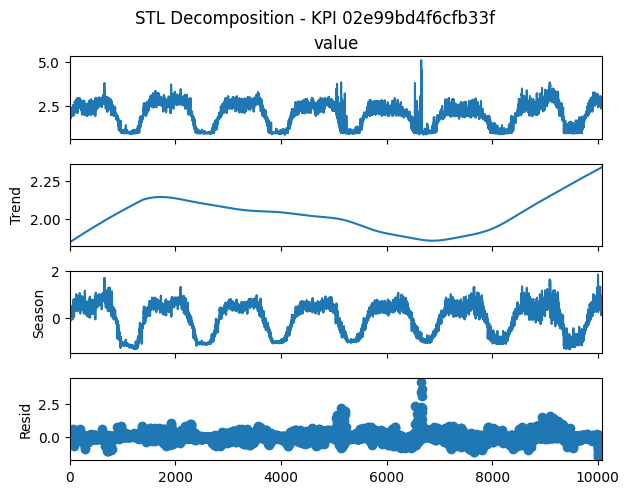

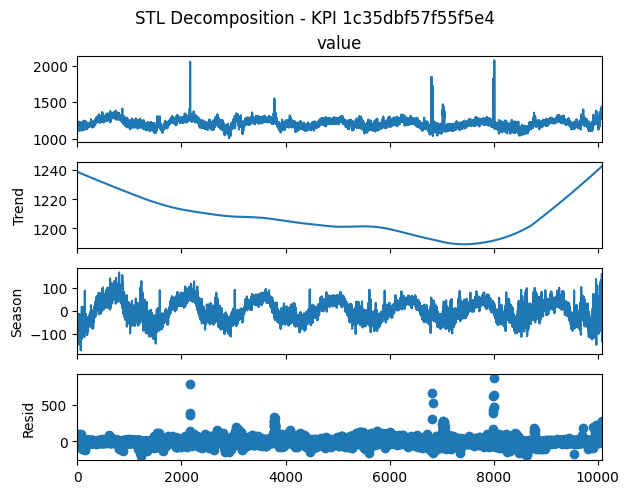

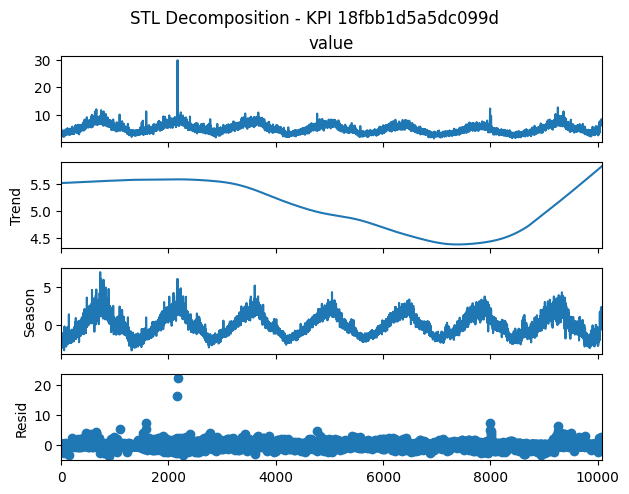

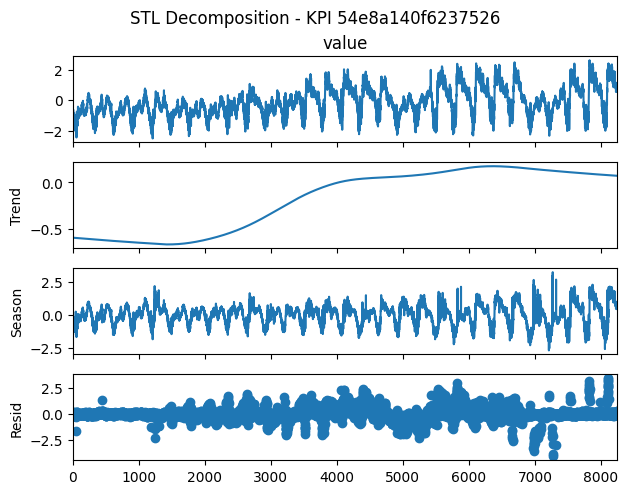

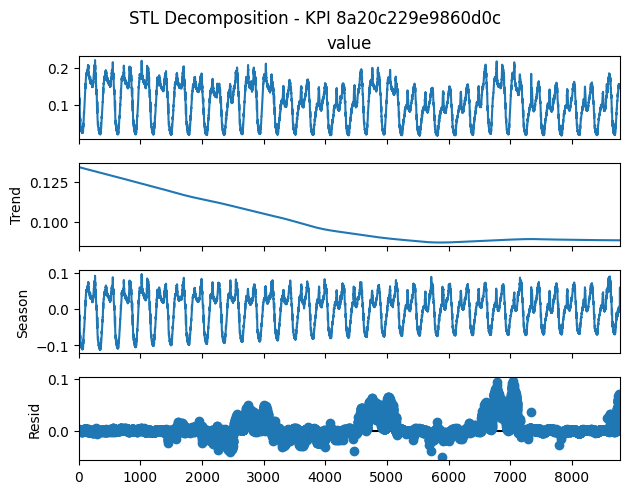

In [25]:
period = 1440
n_points = 1440 * 7

for kpi_id in selected_kpis:

    kpi_df = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")
        .head(n_points)
        .copy()
    )

    series = kpi_df["value"].reset_index(drop=True)

    stl = STL(series, period=period, robust=True)
    result = stl.fit()

    result.plot()
    plt.suptitle(f"STL Decomposition - KPI {kpi_id}", y=1.02)
    plt.show()

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sample_size = 5000

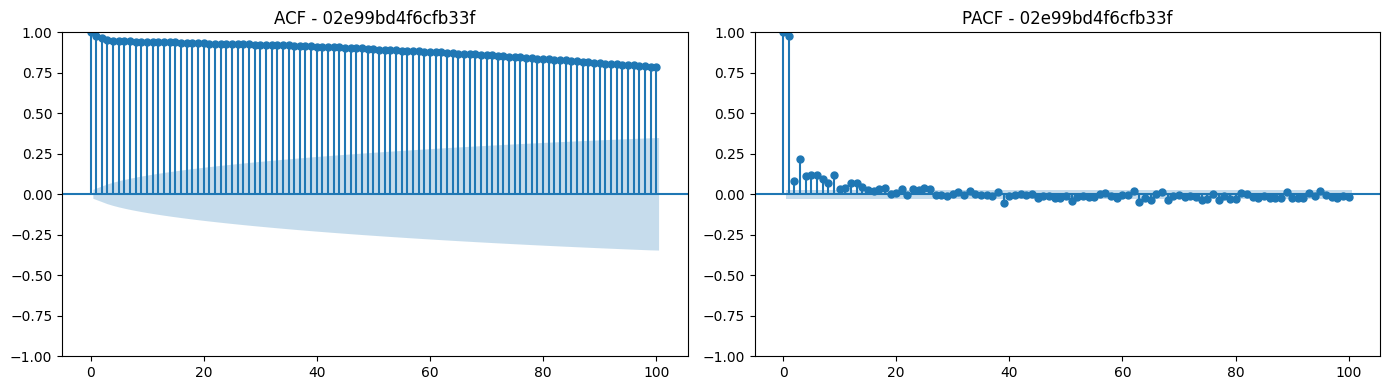

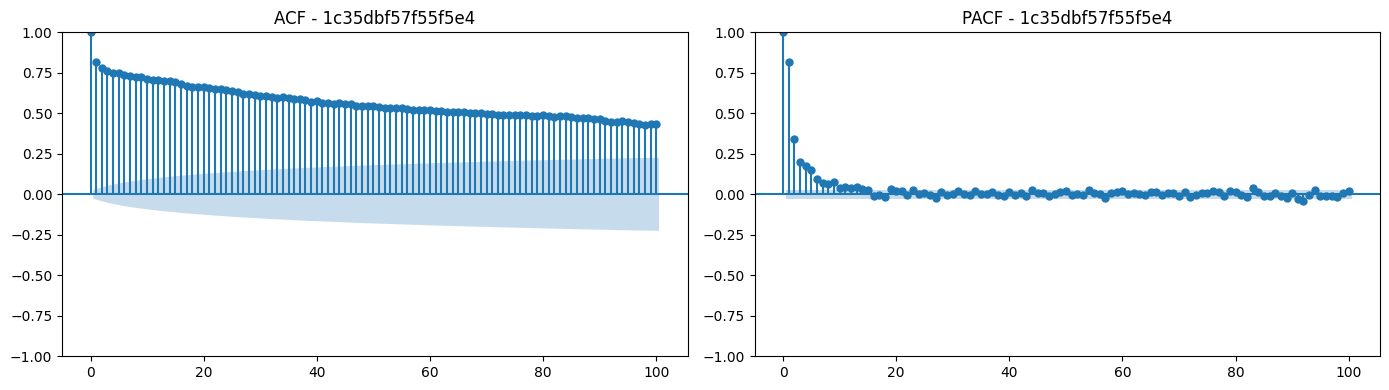

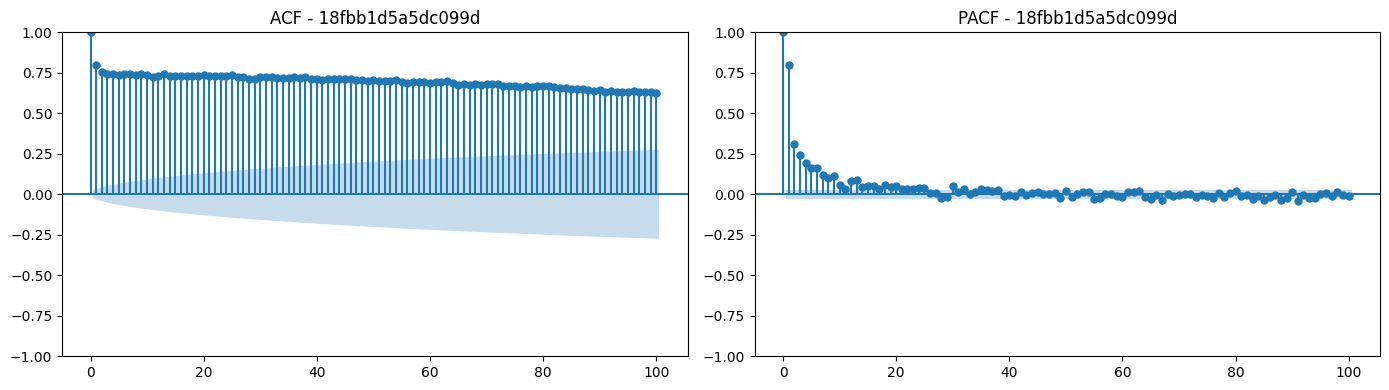

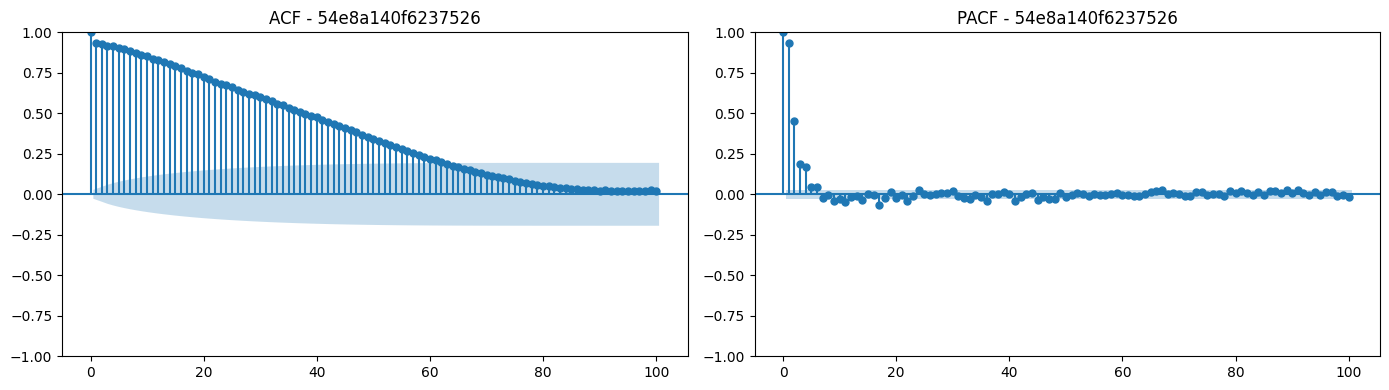

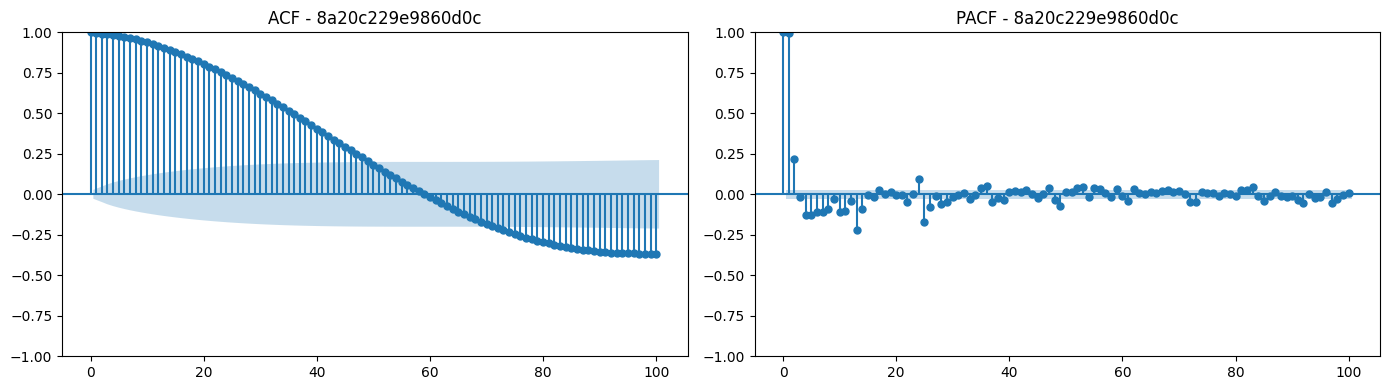

In [27]:
for kpi_id in selected_kpis:

    series = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")["value"]
        .head(5000)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(
        series,
        lags=100,
        ax=axes[0]
    )

    plot_pacf(
        series,
        lags=100,
        ax=axes[1],
        method="ywm"
    )

    axes[0].set_title(f"ACF - {kpi_id}")
    axes[1].set_title(f"PACF - {kpi_id}")

    plt.tight_layout()
    plt.show()

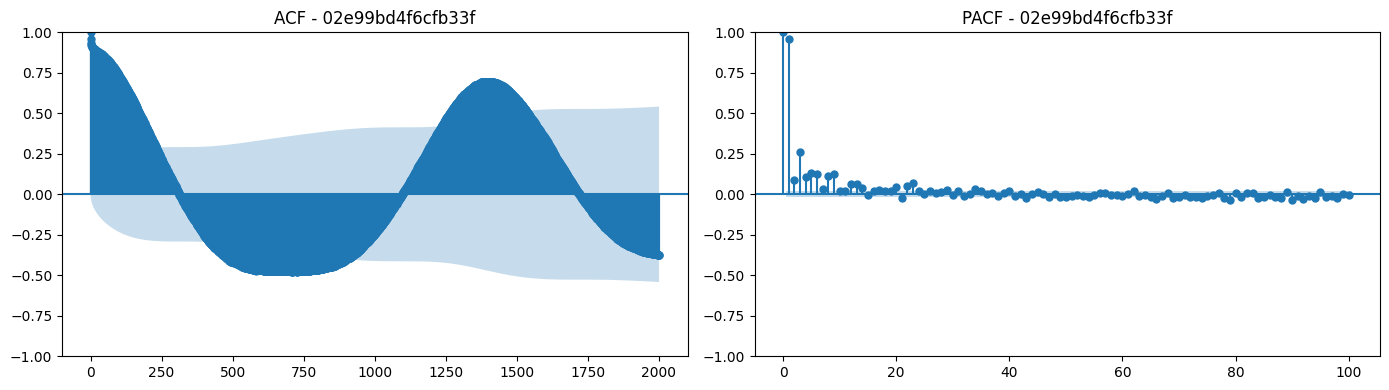

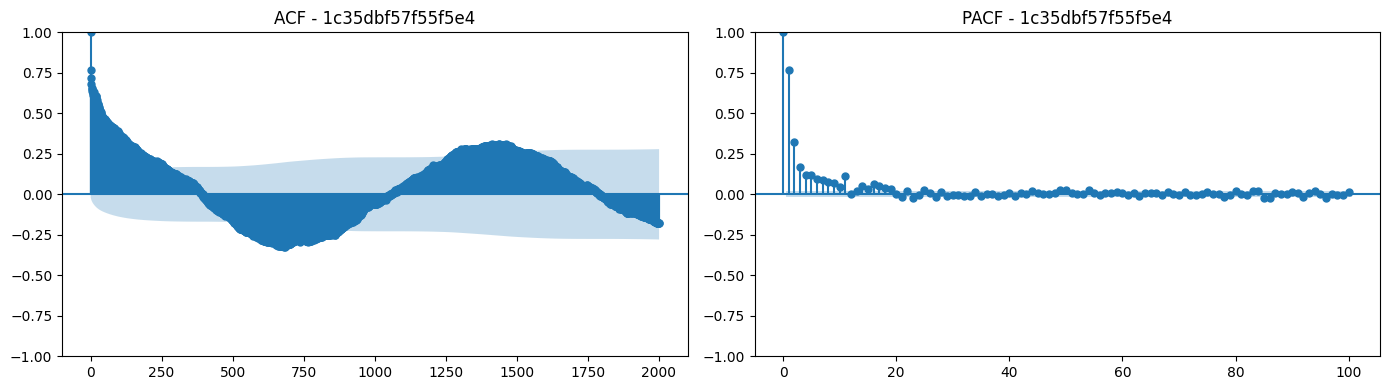

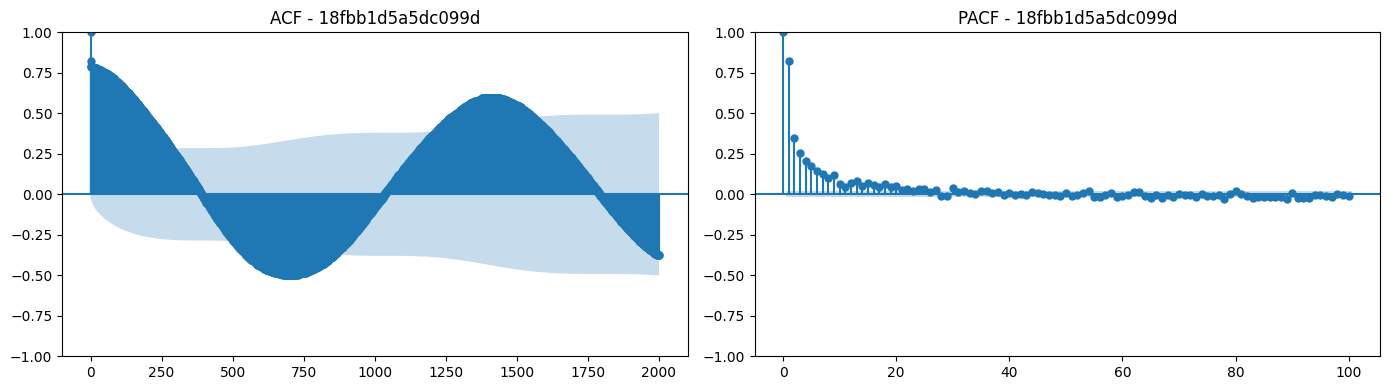

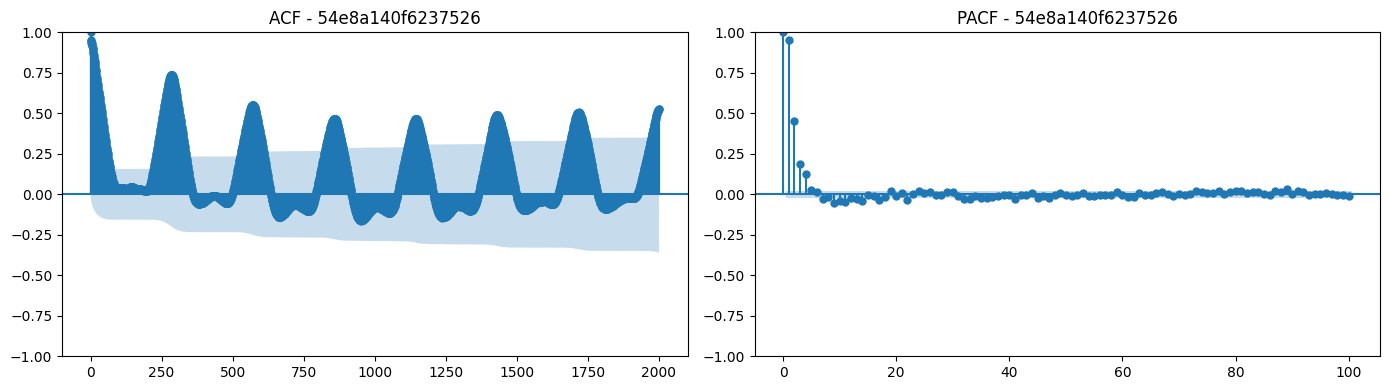

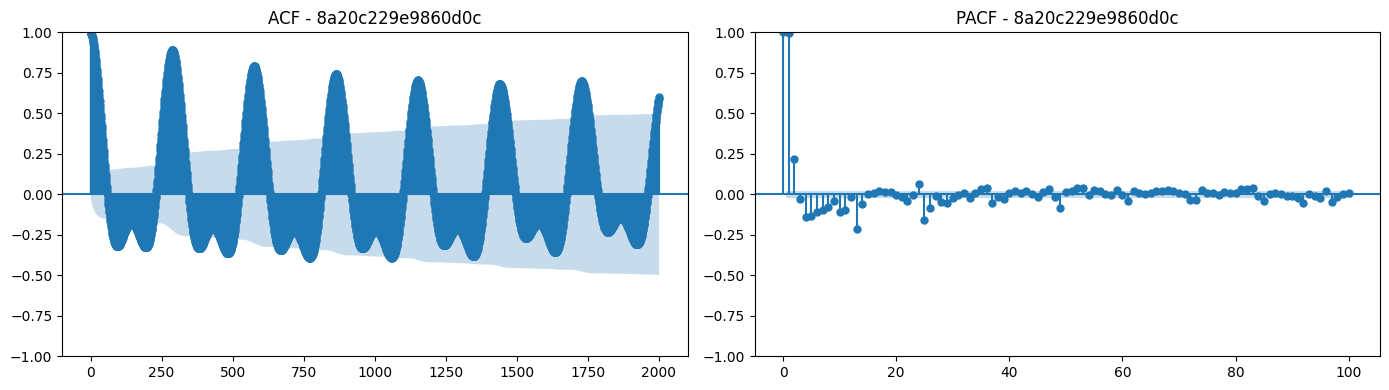

In [29]:
for kpi_id in selected_kpis:

    series = (
        train[train["KPI ID"] == kpi_id]
        .sort_values("timestamp")["value"]
        .head(10000)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(
        series,
        lags=2000,
        ax=axes[0]
    )

    plot_pacf(
        series,
        lags=100,
        ax=axes[1],
        method="ywm"
    )

    axes[0].set_title(f"ACF - {kpi_id}")
    axes[1].set_title(f"PACF - {kpi_id}")

    plt.tight_layout()
    plt.show()

## Cross-metric Correlation Analysis

In [30]:
heatmap_df = (
    train[train["KPI ID"].isin(selected_kpis)]
    .pivot(
        index="timestamp",
        columns="KPI ID",
        values="value"
    )
)

In [31]:
heatmap_df.head()

KPI ID,02e99bd4f6cfb33f,18fbb1d5a5dc099d,1c35dbf57f55f5e4,54e8a140f6237526,8a20c229e9860d0c
timestamp,,,,,
2016-07-22 16:00:00,NaN,NaN,NaN,-1.048088,NaN
2016-07-22 16:05:00,NaN,NaN,NaN,-1.019067,NaN
2016-07-22 16:10:00,NaN,NaN,NaN,-0.968321,NaN
2016-07-22 16:15:00,NaN,NaN,NaN,-0.685366,NaN
2016-07-22 16:20:00,NaN,NaN,NaN,-0.844776,NaN


In [32]:
for kpi in selected_kpis:

    temp = train[train["KPI ID"] == kpi]

    print(kpi)
    print("Start:", temp["timestamp"].min())
    print("End  :", temp["timestamp"].max())
    print()

02e99bd4f6cfb33f
Start: 2017-04-30 16:00:00
End  : 2017-07-31 04:34:00

1c35dbf57f55f5e4
Start: 2017-04-30 16:00:00
End  : 2017-07-31 04:34:00

18fbb1d5a5dc099d
Start: 2017-04-30 16:00:00
End  : 2017-07-31 04:34:00

54e8a140f6237526
Start: 2016-07-22 16:00:00
End  : 2016-08-20 11:45:00

8a20c229e9860d0c
Start: 2016-10-23 16:00:00
End  : 2016-11-23 03:55:00



In [33]:
selected_kpis = [
    "02e99bd4f6cfb33f",
    "1c35dbf57f55f5e4",
    "18fbb1d5a5dc099d"
]

In [34]:
heatmap_df = (
    train[train["KPI ID"].isin(selected_kpis)]
    .pivot(
        index="timestamp",
        columns="KPI ID",
        values="value"
    )
)

heatmap_df.shape

(129270, 3)

In [35]:
heatmap_df.head()

KPI ID,02e99bd4f6cfb33f,18fbb1d5a5dc099d,1c35dbf57f55f5e4
timestamp,,,
2017-04-30 16:00:00,1.901639,2.25,1204.6250
2017-04-30 16:01:00,1.786885,3.15,1182.2500
2017-04-30 16:02:00,2.000000,3.05,1155.1875
2017-04-30 16:03:00,1.885246,3.00,1178.7500
2017-04-30 16:04:00,1.819672,2.30,1151.3750


In [36]:
corr_matrix = heatmap_df.corr()

corr_matrix

KPI ID,02e99bd4f6cfb33f,18fbb1d5a5dc099d,1c35dbf57f55f5e4
KPI ID,,,
02e99bd4f6cfb33f,1.000000,0.019774,0.137250
18fbb1d5a5dc099d,0.019774,1.000000,0.010336
1c35dbf57f55f5e4,0.137250,0.010336,1.000000


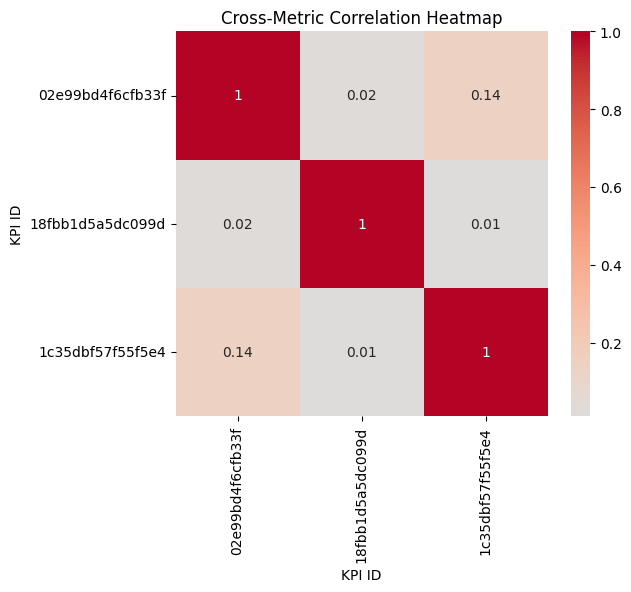

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Cross-Metric Correlation Heatmap")
plt.show()

In [20]:
kpi1 = train[train["KPI ID"] == "02e99bd4f6cfb33f"].copy()

In [21]:
kpi1

,timestamp,value,label,KPI ID
0,2017-04-30 16:00:00,1.901639,0,02e99bd4f6cfb33f
1,2017-04-30 16:01:00,1.786885,0,02e99bd4f6cfb33f
2,2017-04-30 16:02:00,2.000000,0,02e99bd4f6cfb33f
3,2017-04-30 16:03:00,1.885246,0,02e99bd4f6cfb33f
4,2017-04-30 16:04:00,1.819672,0,02e99bd4f6cfb33f
...,...,...,...,...
128557,2017-07-31 04:30:00,2.684211,0,02e99bd4f6cfb33f
128558,2017-07-31 04:31:00,2.526316,0,02e99bd4f6cfb33f
128559,2017-07-31 04:32:00,2.614035,0,02e99bd4f6cfb33f
128560,2017-07-31 04:33:00,2.736842,0,02e99bd4f6cfb33f


In [23]:
kpi1["label"].value_counts()

label
0    118012
1     10550
Name: count, dtype: int64

In [24]:
anomaly_runs = []

run_length = 0

for label in kpi1["label"]:
    if label == 1:
        run_length += 1
    else:
        if run_length > 0:
            anomaly_runs.append(run_length)
            run_length = 0

if run_length > 0:
    anomaly_runs.append(run_length)

In [25]:
pd.Series(anomaly_runs).describe()

count     64.000000
mean     164.843750
std      169.851403
min        1.000000
25%       66.500000
50%      138.000000
75%      201.750000
max      840.000000
dtype: float64

In [18]:
first_kpi = train["KPI ID"].unique()[0]

kpi = train[
    train["KPI ID"] == first_kpi
]

In [19]:
print(first_kpi)
print(kpi.shape)

02e99bd4f6cfb33f
(128562, 4)


In [20]:
kpi["timestamp"] = pd.to_datetime(
    kpi["timestamp"],
    unit="s"
)

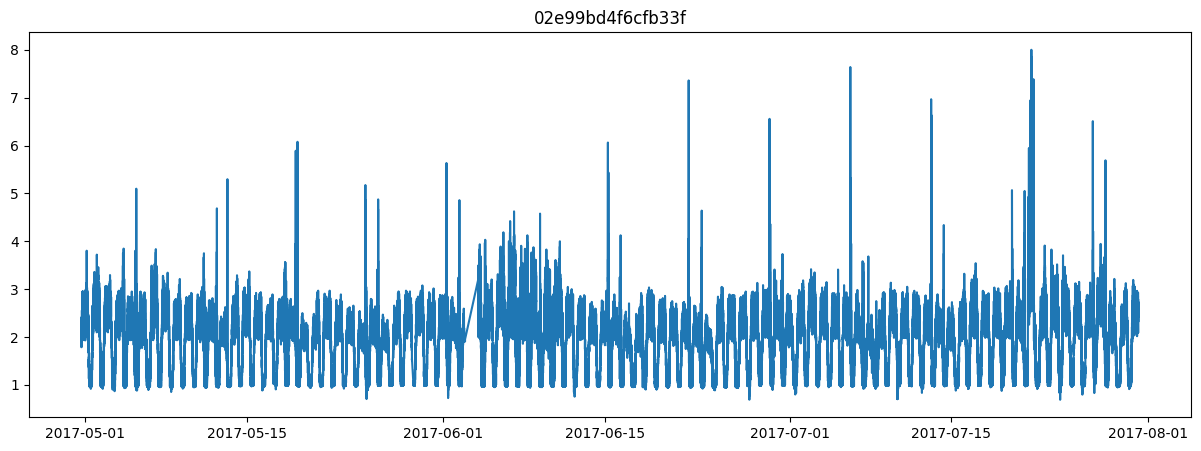

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    kpi["timestamp"],
    kpi["value"]
)

plt.title(first_kpi)

plt.show()

In [24]:
week = kpi.iloc[:10080]

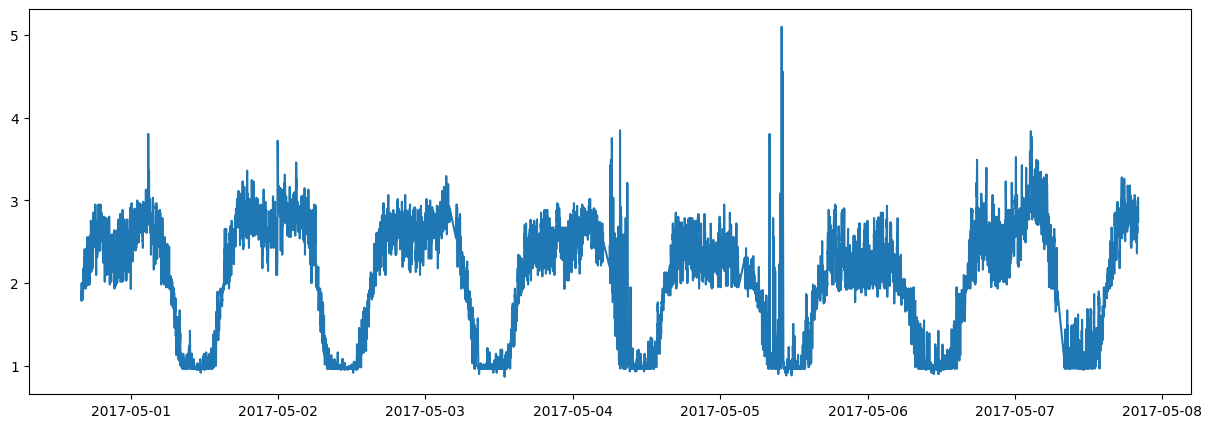

In [25]:
plt.figure(figsize=(15,5))
plt.plot(week["timestamp"], week["value"])
plt.show()

In [26]:
day = kpi.iloc[:1440]

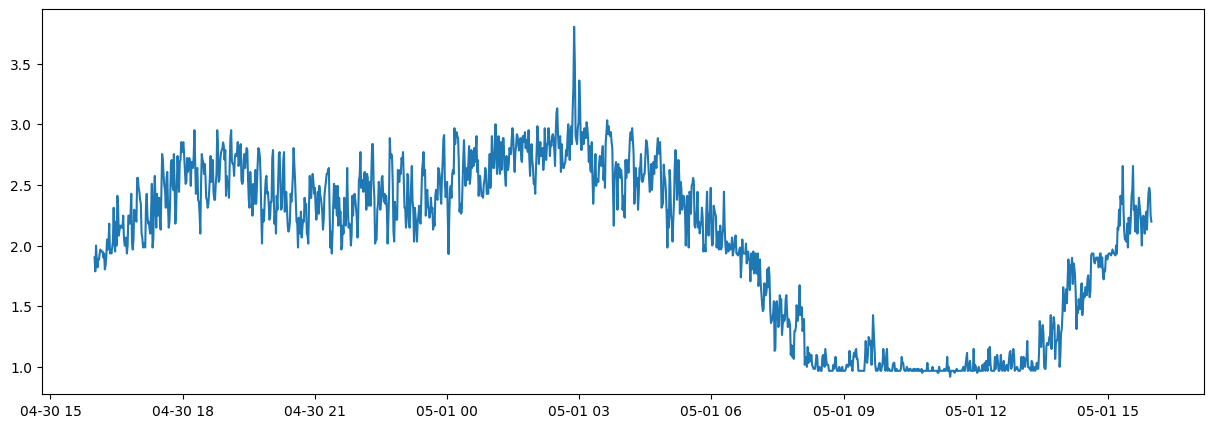

In [27]:
plt.figure(figsize=(15,5))
plt.plot(day["timestamp"], day["value"])
plt.show()

In [28]:
anomaly = kpi[kpi["label"] == 1]

print(len(anomaly))
anomaly.head()

10550


,timestamp,value,label,KPI ID
5046,2017-05-04 06:08:00,2.180328,1,02e99bd4f6cfb33f
5047,2017-05-04 06:09:00,2.721312,1,02e99bd4f6cfb33f
5048,2017-05-04 06:10:00,3.426229,1,02e99bd4f6cfb33f
5049,2017-05-04 06:11:00,2.622951,1,02e99bd4f6cfb33f
5050,2017-05-04 06:12:00,2.065574,1,02e99bd4f6cfb33f


In [29]:
anomaly[["timestamp","value"]]

,timestamp,value
5046,2017-05-04 06:08:00,2.180328
5047,2017-05-04 06:09:00,2.721312
5048,2017-05-04 06:10:00,3.426229
5049,2017-05-04 06:11:00,2.622951
5050,2017-05-04 06:12:00,2.065574
...,...,...
124498,2017-07-28 08:49:00,1.163636
124499,2017-07-28 08:50:00,1.163636
124500,2017-07-28 08:51:00,1.072727
124501,2017-07-28 08:52:00,1.618182


In [30]:
anomaly_idx = kpi[kpi["label"]==1].index[0]

In [31]:
window = kpi.loc[
    anomaly_idx-500:
    anomaly_idx+500
]

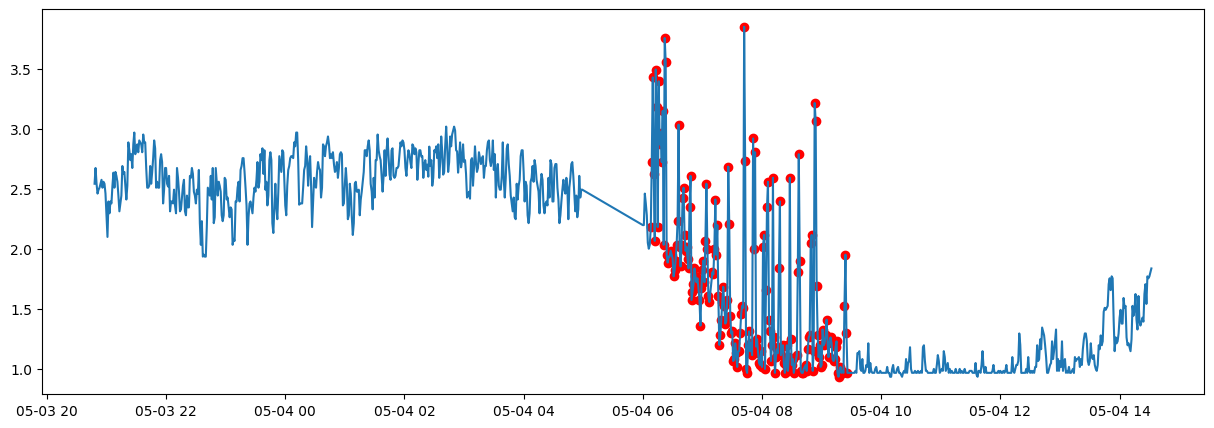

In [32]:
plt.figure(figsize=(15,5))

plt.plot(
    window["timestamp"],
    window["value"]
)

plt.scatter(
    window[window["label"]==1]["timestamp"],
    window[window["label"]==1]["value"],
    color="red"
)

plt.show()

In [33]:
kpi["hour"] = kpi["timestamp"].dt.hour

hourly = (
    kpi.groupby("hour")["value"]
    .mean()
    .reset_index()
)

hourly

,hour,value
0,0,2.398249
1,1,2.400889
2,2,2.451819
3,3,2.442021
4,4,2.383609
5,5,2.219939
6,6,1.954734
7,7,1.441800
8,8,1.178857
9,9,1.102636


<Axes: >

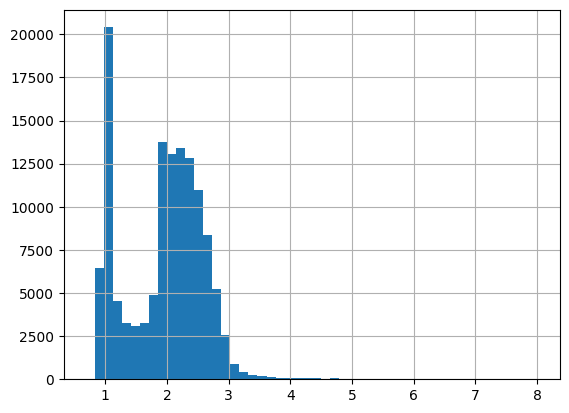

In [39]:
kpi["value"].hist(bins=50)